# Buzzard flock -> mock obs_maps.h5

Builds the Buzzard N-body flock into a single `data/obs/buzzard_flock_obs_maps.h5`, in exactly the
`obs/maps` + `obs/cls_raw` schema `msfm/apps/run_single_postprocessing.py` writes for the CosmoGrid
benchmark mocks.
That is what makes it evaluable with no deep_lss changes: point
`deep_lss.apps.run_evaluation --include_mocks --data_dir <dlss data dir>` at it and
`deep_lss.utils.evaluation.discover_mock_labels` / `evaluate_obs_mocks` pick it up as label
`buzzard_flock`.
Copy the file into `<dlss data dir>/obs/` first, next to the CosmoGrid benchmarks, since that is
the directory `--data_dir` names.

Unlike every CosmoGrid mock, Buzzard is not at the fiducial cosmology, so its truth is written into
the file as a `cosmo/<param>` group and read back by `evaluation.mock_truth_cosmo`.

The heavy step is ~25e6 ellipticity draws per tomographic bin per member, so run this on a compute
node rather than a login node. The `torch_env` kernel is enough: `observation.make_shape_noise_map`
imports `tensorflow` / `tensorflow_probability`, and both are installed there.

In [1]:
%load_ext autoreload
%autoreload 2

import os

import h5py
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.utils import buzzard, files, observation

### Config

In [2]:
conf = files.load_config("../configs/v18/default.yaml")
n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)

masks_metacal = files.get_tomo_masks(conf, nest_out=False)["metacal"]

### Flock members

`MEMBERS`/`LENS_J`/`LENS_K` are the member -> lens-catalog mapping that used to live in
`pack_buzzard_flock.py` (now removed).
Each member directory under `FLOCK_DIR` holds the pure-signal lensing file; the maglim clustering
counterpart is unaffected by the shape-noise change and is read from the copies already in
`data/deprecated/mock_observations/Buzzard_flock/`.

`WL_only` in the filename is load-bearing.
Every member directory also still holds the superseded `..._shear_noise+WL_iseed_42_varied.h5`,
whose gamma already contains shape noise at ~16x the signal amplitude; picking that one up would
double-count the noise and fail nowhere downstream.
`build_member` re-checks the amplitude per member rather than trusting the name.

In [3]:
MEMBERS = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
LENS_J = [0, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 11, 11]
LENS_K = ["a"] + 7 * ["a", "b"]

FLOCK_DIR = "/capstor/store/cscs/swissai/a0158/athomsen/buzzard_flock"
LENSING_NAME = "DESY3_mock_observation_buzzard_flock_v14_shear_WL_only.h5"
CLUSTERING_DIR = "../data/deprecated/mock_observations/Buzzard_flock"

lensing_files = {member: f"{FLOCK_DIR}/{member}/{LENSING_NAME}" for member in MEMBERS}
clustering_files = [
    f"{CLUSTERING_DIR}/DESY3_mock_observation_Buzzard_{j}_Y3{k}.h5" for j, k in zip(LENS_J, LENS_K)
]

missing = [f for f in list(lensing_files.values()) + clustering_files if not os.path.exists(f)]
assert not missing, f"missing {len(missing)} input file(s): {missing}"

### Add v18 shape noise and forward-model each available member

The delivered lensing file is signal-only, so the shape noise has to be generated here.
This reproduces the `count` branch of `analysis.modelling.lensing.shape_noise` in
`configs/v18/default.yaml`: Poisson-resample the N-body `metacal/galaxy_counts_bin*` map, then draw
one ellipticity per galaxy from the real DES Y3 catalog through
`observation.make_shape_noise_map`.

Unlike the CosmoGrid path, the counts do not go through `clustering.galaxy_density_to_count` and no
bias or imaging systematics are re-imprinted: these are already simulated source counts carrying
the N-body source clustering, not a density field that needs a linear-bias model.
Buzzard is also ~8% denser than the `survey.metacal.n_gal` of the real survey, so its shape noise
comes out slightly below the DES Y3 level.

Noise is seeded from the member index, so re-running this reproduces the same realization.

In [4]:
def build_member(member, lens_j, lens_k, lensing_file):
    wl_gamma_map = buzzard.get_lensing_map(lensing_file)
    counts = buzzard.get_metacal_counts(lensing_file)

    # the maps must already sit in the rotated frame that the footprint mask defines, since
    # forward_model_observation_map and make_shape_noise_map both index it by pixel
    assert np.array_equal(counts > 0, masks_metacal > 0), f"member {member} is not in the v18 frame"

    # a signal-only file has std(gamma) ~ 0.002 on the footprint; with shape noise it is ~0.03
    signal_scatter = wl_gamma_map[masks_metacal[:, 0] > 0, 0, 0].std()
    assert signal_scatter < 0.01, f"member {member} looks noisy already: std(gamma1) = {signal_scatter:.4f}"

    clustering_file = f"{CLUSTERING_DIR}/DESY3_mock_observation_Buzzard_{lens_j}_Y3{lens_k}.h5"
    gc_count_map = buzzard.get_clustering_map(clustering_file)

    noisy_counts = np.stack(
        [np.random.default_rng([member, i_z]).poisson(counts[:, i_z]) for i_z in range(counts.shape[-1])],
        axis=-1,
    )
    noise = observation.make_shape_noise_map(noisy_counts, conf, method="count", noise_seed=member)

    obs_map, obs_cl_raw, _ = observation.forward_model_observation_map(
        wl_gamma_map=wl_gamma_map + noise,
        gc_count_map=gc_count_map,
        conf=conf,
        apply_norm=False,
        with_padding=True,
        nest_in=False,
    )
    return obs_map, obs_cl_raw


obs_maps = []
obs_cls_raw = []
built_members = []
for member, lensing_file in lensing_files.items():
    i = MEMBERS.index(member)
    obs_map, obs_cl_raw = build_member(member, LENS_J[i], LENS_K[i], lensing_file)
    obs_maps.append(obs_map)
    obs_cls_raw.append(obs_cl_raw)
    built_members.append(member)
    print(f"member {member:2d} (Buzzard_{LENS_J[i]}_Y3{LENS_K[i]}) done")

obs_maps = np.stack(obs_maps, axis=0)
obs_cls_raw = np.stack(obs_cls_raw, axis=0)

26-09-04 10:15:30     files.py INF   Loaded the noise file 


26-09-04 10:15:33 observation. INF   Forward modeling the weak lensing map 


26-09-04 10:15:36 observation. INF   Forward modeling the galaxy clustering map 


member  0 (Buzzard_0_Y3a) done


26-09-04 10:15:42     files.py INF   Loaded the noise file 


...

member 14 (Buzzard_11_Y3a) done


26-09-04 10:17:50     files.py INF   Loaded the noise file 


26-09-04 10:17:54 observation. INF   Forward modeling the weak lensing map 


26-09-04 10:17:55 observation. INF   Forward modeling the galaxy clustering map 


member 15 (Buzzard_11_Y3b) done


### Write the single obs_maps.h5 file

Unnormalized (`apply_norm=False`), like every CosmoGrid mock: `analysis.normalization` is applied
at evaluation time in `evaluate_obs_mocks`.
`cosmo/<param>` carries the Buzzard truth, with NaN for the parameters the simulation has no single
value for (the baryon parameters, since it is dark-matter-only, and the galaxy biases, since it is
populated with ADDGALS).

In [5]:
out_file = "../data/obs/buzzard_flock_obs_maps.h5"
os.makedirs(os.path.dirname(out_file), exist_ok=True)

cosmo = buzzard.get_cosmo(conf)

with h5py.File(out_file, "w") as f:
    f.create_dataset("obs/maps", data=obs_maps)
    f.create_dataset("obs/cls_raw", data=obs_cls_raw)
    for param, value in cosmo.items():
        f.create_dataset(f"cosmo/{param}", data=np.float64(value))
    f.attrs["members"] = built_members

print(f"wrote {out_file}")
print(f"  members    {built_members}")
print(f"  obs/maps   {obs_maps.shape}")
print(f"  obs/cls_raw {obs_cls_raw.shape}")
print(f"  cosmo      {cosmo}")

wrote ../data/obs/buzzard_flock_obs_maps.h5
  members    [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  obs/maps   (15, 458752, 8)
  obs/cls_raw (15, 1536, 36)
  cosmo      {'Om': 0.286, 's8': 0.82, 'Ob': 0.047, 'H0': 70.0, 'ns': 0.96, 'w0': -1, 'bary_Mc': nan, 'bary_nu': nan, 'Aia': 0.0, 'n_Aia': nan, 'bta': 0.0, 'bg1': nan, 'bg2': nan, 'bg3': nan, 'bg4': nan}


### Sanity plots (first built member)

26-09-04 10:18:06     files.py INF   Loaded the noise file 


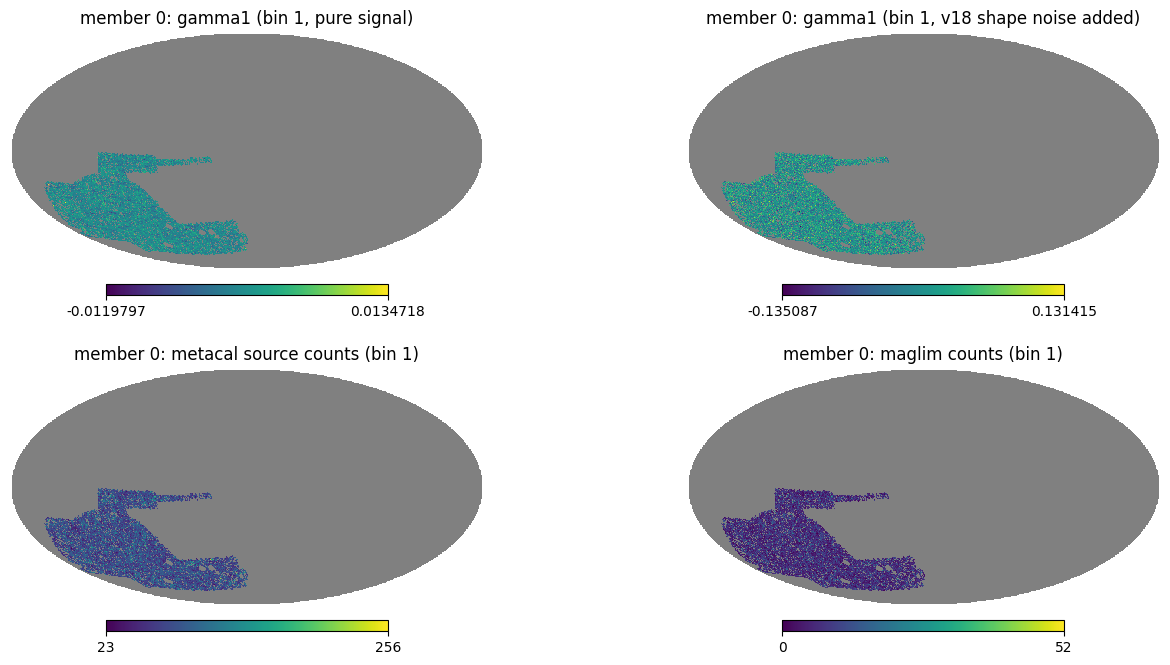

In [6]:
member = built_members[0]
i = MEMBERS.index(member)

gamma = buzzard.get_lensing_map(lensing_files[member])
counts = buzzard.get_metacal_counts(lensing_files[member])
noisy_counts = np.stack(
    [np.random.default_rng([member, i_z]).poisson(counts[:, i_z]) for i_z in range(counts.shape[-1])],
    axis=-1,
)
noisy_gamma = gamma + observation.make_shape_noise_map(noisy_counts, conf, method="count", noise_seed=member)

gc_count_map = buzzard.get_clustering_map(
    f"{CLUSTERING_DIR}/DESY3_mock_observation_Buzzard_{LENS_J[i]}_Y3{LENS_K[i]}.h5"
)

empty = counts[:, 0] == 0
panels = [
    (gamma[:, 0, 0], "gamma1 (bin 1, pure signal)"),
    (noisy_gamma[:, 0, 0], "gamma1 (bin 1, v18 shape noise added)"),
    (counts[:, 0], "metacal source counts (bin 1)"),
    (gc_count_map[:, 0], "maglim counts (bin 1)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (m, title) in zip(axes.ravel(), panels):
    m = m.copy()
    m[empty] = hp.UNSEEN
    plt.axes(ax)
    hp.mollview(m, title=f"member {member}: {title}", hold=True)